<a href="https://colab.research.google.com/github/turtul17/tyttt/blob/main/Aviation_Disruption_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
!pip install google-cloud-bigquery pandas scikit-learn

📌 Note:

Installs required libraries for:

Data extraction (BigQuery)
Data handling (Pandas)
Machine Learning (Scikit-learn)
🎯 Importance:

Ensures all dependencies are available in the Colab environment.

In [52]:
from google.colab import auth
auth.authenticate_user()

📌 Note:

Authenticates your Google account to access BigQuery securely.

🎯 Importance:
Required to fetch data from BigQuery
Enables cloud-to-notebook integration

In [53]:
from google.cloud import bigquery
client = bigquery.Client(project='eastern-adapter-466102-d2')

📌 Note:

Creates a client connection to interact with BigQuery datasets.

🎯 Importance:

Acts as a bridge between:Colab ↔ BigQuery

In [54]:
query = """
SELECT *
FROM `eastern-adapter-466102-d2.Aviation_Data.ml_feature_table`
"""

df = client.query(query).to_dataframe()

df.head()

,airline,total_cancellations,total_reroutes,avg_delay,avg_cost,avg_loss,avg_airport_disruption,total_conflicts
0,Qatar Airways,6,0,NaN,NaN,3100000.0,140.500000,24
1,Emirates,6,0,NaN,NaN,4200000.0,196.111111,54
2,Saudia,5,0,NaN,NaN,1240000.0,150.285714,35
3,Turkish Airlines,5,2,49.0,43680.0,2400000.0,166.125000,40
4,El Al,3,0,NaN,NaN,2800000.0,157.000000,18


📌 Note:

Executes SQL query and loads data into a Pandas DataFrame.

🎯 Importance:
Eliminates need for CSV download
Enables real-time data access
🧠 Concept:
Cloud Data → Python DataFrame

In [55]:
# Drop non-numeric column
df = df.drop(columns=["airline"])

df = df.fillna(0)

# Features and target
X = df.drop(columns=["total_cancellations"])
y = df["total_cancellations"]

📌 Note:
Removes categorical column (airline)
Separates features (X) and target (y)

🎯 Importance:
Prepares dataset for machine learning algorithms.

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

📌 Note:

Splits data into:

Training set (80%)
Testing set (20%)
🎯 Importance:
Prevents overfitting
Enables model evaluation

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100)
gb = GradientBoostingRegressor()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor()

📌 Note:

Three models are trained:

Linear Regression (baseline)
Random Forest (ensemble)
Gradient Boosting (advanced)
🎯 Importance:

Allows comparison of different ML approaches.

In [58]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

📌 Note:

Generates predictions using trained models.

🎯 Importance:

Used to evaluate model performance.

In [59]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    print("RMSE:", rmse)
    print("R2 Score:", r2_score(y_test, y_pred))

📌 Note:

Evaluates models using:

RMSE (error)
R² (accuracy)

🎯 Importance:
Determines best-performing model.

🧠 Interpretation:
Metric            	Meaning
RMSE	              Lower = better
R²	                Closer to 1 = better

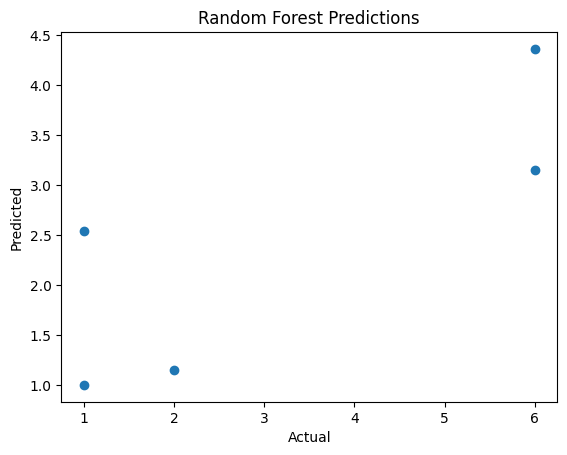

In [60]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

📌 Note:

Plots actual vs predicted values.

🎯 Importance:
Visual validation of model
Shows prediction accuracy

In [61]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feat_imp

,Feature,Importance
5,total_conflicts,0.802153
3,avg_loss,0.119532
4,avg_airport_disruption,0.041920
0,total_reroutes,0.020857
2,avg_cost,0.009814
1,avg_delay,0.005724


📌 Note:

Identifies most influential features.

🎯 Importance:
Explains model decisions
Key requirement for IEEE
🧠 Example Insight:
High importance → strong impact on cancellations